In [1]:
import os
os.chdir("C:/journal_project")
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report
from xgboost import XGBClassifier

In [2]:
FEATURE_COLS = ["hr", "hrv", "eda", "wrist_temp", "co2_noisy", "lux_noisy", "posture_cm"]
df = pd.read_csv("outputs/unified_features.csv").dropna(subset=FEATURE_COLS)

le = LabelEncoder()
y = le.fit_transform(df["ground_truth"])
groups = df["subject"].values
X = df[FEATURE_COLS].values
scale_pos_weight = (y == 0).sum() / (y == 1).sum()

In [3]:
def build_base_learners():
    return {
        "rf": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
        "xgb": XGBClassifier(n_estimators=200, max_depth=4, scale_pos_weight=scale_pos_weight,
                              eval_metric="logloss", random_state=42),
        "gb": GradientBoostingClassifier(random_state=42),
        "lr": LogisticRegression(max_iter=3000, class_weight="balanced"),
    }

def manual_stacking_predict(X_train, y_train, groups_train, X_test, inner_splits=3):
    """
    Leakage-safe stacking with CONSISTENT scaling throughout: one scaler is
    fit on the outer-training set and used for every downstream step, fixing
    the train/test scale mismatch that caused the earlier collapse.
    """
    n_train = len(y_train)
    base_names = list(build_base_learners().keys())
    oof_preds = np.zeros((n_train, len(base_names)))

    # Fit ONE scaler on the full outer-training set; reuse it everywhere
    final_scaler = StandardScaler()
    X_train_scaled = final_scaler.fit_transform(X_train)
    X_test_scaled = final_scaler.transform(X_test)

    # Inner subject-grouped CV using the SAME scaled features
    inner_cv = StratifiedGroupKFold(n_splits=inner_splits, shuffle=True, random_state=0)
    for inner_tr_idx, inner_val_idx in inner_cv.split(X_train_scaled, y_train, groups=groups_train):
        learners = build_base_learners()
        for i, name in enumerate(base_names):
            learners[name].fit(X_train_scaled[inner_tr_idx], y_train[inner_tr_idx])
            oof_preds[inner_val_idx, i] = learners[name].predict_proba(X_train_scaled[inner_val_idx])[:, 1]

    # Meta-training features: OOF base predictions + SCALED original features (passthrough)
    meta_X_train = np.hstack([oof_preds, X_train_scaled])
    meta_learner = LogisticRegression(max_iter=3000, class_weight="balanced")
    meta_learner.fit(meta_X_train, y_train)

    # Train base learners on the full outer-training set (scaled) for final test predictions
    final_learners = build_base_learners()
    test_base_preds = np.zeros((len(X_test), len(base_names)))
    for i, name in enumerate(base_names):
        final_learners[name].fit(X_train_scaled, y_train)
        test_base_preds[:, i] = final_learners[name].predict_proba(X_test_scaled)[:, 1]

    meta_X_test = np.hstack([test_base_preds, X_test_scaled])
    return meta_learner.predict(meta_X_test)

In [4]:
N_REPEATS = 10
fold_f1, fold_acc = [], []
all_preds, all_true = [], []

for repeat in range(N_REPEATS):
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=repeat)
    for train_idx, test_idx in sgkf.split(X, y, groups=groups):
        preds = manual_stacking_predict(X[train_idx], y[train_idx], groups[train_idx], X[test_idx])
        all_preds.extend(preds)
        all_true.extend(y[test_idx])
        fold_f1.append(f1_score(y[test_idx], preds, average="macro", zero_division=0))
        fold_acc.append(accuracy_score(y[test_idx], preds))
    print(f"Repeat {repeat+1}/{N_REPEATS} done")

print(f"\nLeakage-corrected Stacking Ensemble: F1 = {np.mean(fold_f1):.4f} (SD={np.std(fold_f1):.4f})")
print(f"Accuracy = {np.mean(fold_acc)*100:.2f}%")

Repeat 1/10 done
Repeat 2/10 done
Repeat 3/10 done
Repeat 4/10 done
Repeat 5/10 done
Repeat 6/10 done
Repeat 7/10 done
Repeat 8/10 done
Repeat 9/10 done
Repeat 10/10 done

Leakage-corrected Stacking Ensemble: F1 = 0.7720 (SD=0.1033)
Accuracy = 80.44%


In [5]:
summary = pd.read_csv("outputs/model_comparison_results.csv")
summary = summary[summary["Model"] != "Proposed_Stacking_Ensemble"]  # remove old leaky row
summary = pd.concat([summary, pd.DataFrame([{
    "Model": "Proposed_Stacking_Ensemble", "Mean_Macro_F1": np.mean(fold_f1), "Std": np.std(fold_f1)
}])], ignore_index=True).sort_values("Mean_Macro_F1", ascending=False)
summary.to_csv("outputs/model_comparison_results.csv", index=False)

scores_df = pd.read_csv("outputs/per_fold_f1_scores.csv")
scores_df["Proposed_Stacking_Ensemble"] = fold_f1  # overwrite old leaky column
scores_df.to_csv("outputs/per_fold_f1_scores.csv", index=False)

print(summary.to_string(index=False))

                     Model  Mean_Macro_F1      Std  Accuracy_Mean  Accuracy_SD
Proposed_Stacking_Ensemble       0.772023 0.103286            NaN          NaN
                   XGBoost       0.748420 0.117006            NaN          NaN
        LogisticRegression       0.743812 0.130790            NaN          NaN
              RandomForest       0.730598 0.091181            NaN          NaN
          GradientBoosting       0.723334 0.113563            NaN          NaN
                       MLP       0.683362 0.109444            NaN          NaN
                RuleEngine       0.667595 0.129009            NaN          NaN
                       SVM       0.652526 0.119232            NaN          NaN


In [6]:
summary_check = pd.read_csv("outputs/model_comparison_results.csv")
print(summary_check["Model"].tolist())
scores_check = pd.read_csv("outputs/per_fold_f1_scores.csv")
print(scores_check.columns.tolist())

['Proposed_Stacking_Ensemble', 'XGBoost', 'LogisticRegression', 'RandomForest', 'GradientBoosting', 'MLP', 'RuleEngine', 'SVM']
['LogisticRegression', 'SVM', 'RandomForest', 'GradientBoosting', 'MLP', 'RuleEngine', 'Proposed_Stacking_Ensemble', 'XGBoost']


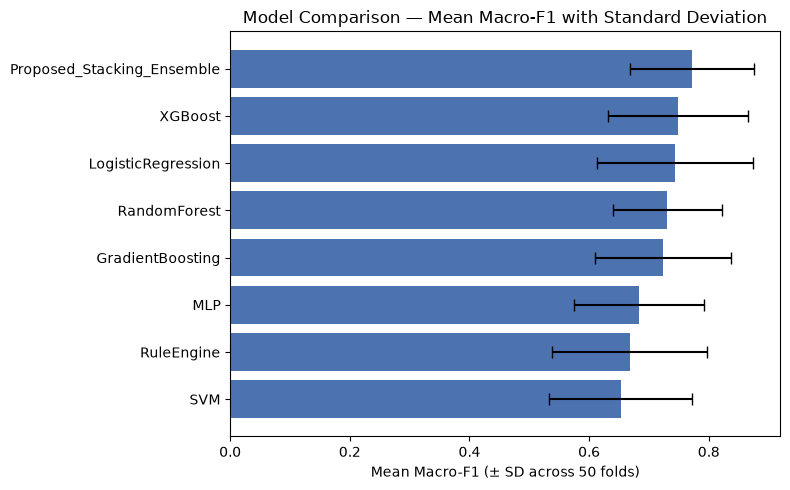

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

summary = pd.read_csv("outputs/model_comparison_results.csv").sort_values("Mean_Macro_F1", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(summary["Model"], summary["Mean_Macro_F1"], xerr=summary["Std"], capsize=4, color="#4C72B0")
plt.xlabel("Mean Macro-F1 (± SD across 50 folds)")
plt.title("Model Comparison — Mean Macro-F1 with Standard Deviation")
plt.tight_layout()
plt.savefig("outputs/figure4_model_comparison_300dpi.jpg", dpi=300, bbox_inches="tight")
plt.show()

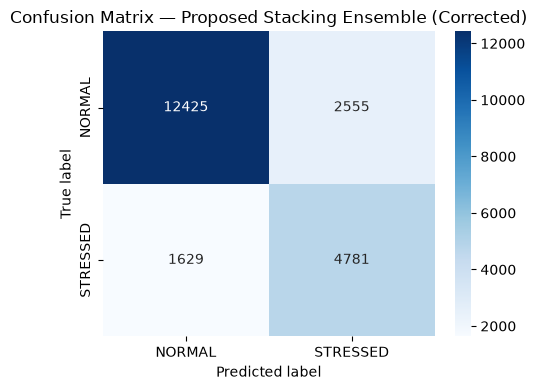

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["NORMAL", "STRESSED"], yticklabels=["NORMAL", "STRESSED"])
plt.title("Confusion Matrix — Proposed Stacking Ensemble (Corrected)")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix_best_model_300dpi.jpg", dpi=300, bbox_inches="tight")
plt.show()